# 511 keV ScAtt Binning for Image Deconvolution

updated on 2025-11-07

This notebook focuses on how to produce the binned datasets with the spacecraft attitude (ScAtt) binning method.
Using a 511keV thin disk 3-month simulation dataset created for DC2, an example of the image analysis will be presented.
After running through this notebook, you can go to the next notebook, [511keV-ScAtt-ImageDeconvolution.ipynb](https://github.com/cositools/cosipy/blob/main/docs/tutorials/image_deconvolution/optional/scatt_binned_data_w_local_coordinate/511keV-ScAtt-ImageDeconvolution.ipynb).

### Notes on the coordinate system of Compton Data Space in the image deconvolution ###

We have two options for the coordinate system to describe the Compton scattering direction ($\chi\psi$), namely Galactic coordinates or  detector coordinates.

Using Galactic coordinates is intuitive, and the spectral fitting adopts this convention. However, using Galactic coordinates for the iamging is computationally expensive since we need to convert the detector response into the Galactic coordinates for each pixel in the sky. Thus, the pre-computed converted response are provided in DC2 and DC3 for several main sources (511 keV, Al-26, Ti-44, continuum). These pre-computed responses assume that we analyze 3-month data without extracting some time intervals, and the pixel resolution of the model map is already fixed. While there is less flexibility in binning/modeling, it is relatively fast to perform the image deconvolution since the most computationally heavy part, the coordinate conversion of the response, can be skipped.

Using the detector coordinates to describe the Compton scattering direction ($\chi\psi$) may not be as intuitive. However, the advantage is that we do not have to convert the response matrix; instead, we convert the model map into the detector coordinate. Because the model map is generally smaller in size than the response, we can compute this coordinate conversion quickly. The disadvantage of this method is that we need more bins due to continuous pointing changes of the COSI satellite. Since COSI is an all-sky monitoring satellite with ∼90-minute orbits, it changes its pointing by ∼4 degrees every minute. Thus, in this case, we need to divide the data into several bins so that astronomical sources can be considered at rest in the detector coordinate for each bin within the COSI's angular resolution. A straightforward approach would be to divide the data every $\sim$15 seconds, considering that the COSI's angular resolution is an order of degrees. However, we need $5\times10^5$ time bins for 3-month observations, which makes the event histogram very large. To avoid this, the spacecraft attitude (ScAtt) binning method is introduced. Instead of binning data over time, we first analyze the satellite attitude and find the time intervals when the satellite has almost the same attitude within the angular resolution. Then, we add the events in such intervals into the same CDS bin. In the DC2 simulation, the orbit inclination is 0 degrees (5 degrees for DC3). In this case, the number of the scatt bins is only ~1000 which makes the computation more executable. With this method, at least in DC2 and DC3, we can perform the image deconvolution using the original response matrix and have flexibilities to change binning/modeling, e.g., the pixel resolution can be changed in a relatively easy way.

While both methods have pros and cons, our baseline is to eventually use the Galactic coordinate. But we still need to carefully investigate how it will be scaled with longer exposure, finer pixel resolution, etc. Thus, we provide the notebooks of both methods for the image deconvolution to be used for DC2 and DC3.

For the 511 keV image analysis, the following notebooks are based on the scatt binning method
- [ScAttBinning/511keV-ScAtt-DataReduction.ipynb](https://github.com/cositools/cosipy/blob/main/docs/tutorials/image_deconvolution/optional/scatt_binned_data_w_local_coordinate/511keV-ScAtt-DataReduction.ipynb)
- [ScAttBinning/511keV-ScAtt-ImageDeconvolution.ipynb](https://github.com/cositools/cosipy/blob/main/docs/tutorials/image_deconvolution/optional/scatt_binned_data_w_local_coordinate/511keV-ScAtt-ImageDeconvolution.ipynb)

Note: data that is binned in this notebook is not suitable for analysis performed in Galactic coordinates, such as the spectral fitting or Galactic coordinate imaging.

[GalacticCDS/511keV-Galactic-ImageDeconvolution.ipynb](https://github.com/cositools/cosipy/blob/main/docs/tutorials/image_deconvolution/511keV-Galactic-ImageDeconvolution.ipynb) uses Galactic coordinates.

In [1]:
import logging
import sys
logger = logging.getLogger('cosipy')
logger.setLevel(logging.INFO)
logger.addHandler(logging.StreamHandler(sys.stdout))

In [2]:
from histpy import Histogram, HealpixAxis, Axis, Axes
from mhealpy import HealpixMap
from astropy.coordinates import SkyCoord, cartesian_to_spherical, Galactic

from cosipy.response import FullDetectorResponse
from cosipy.spacecraftfile import SpacecraftFile
from cosipy.data_io import UnBinnedData, BinnedData
from cosipy.image_deconvolution import SpacecraftAttitudeExposureTable, CoordsysConversionMatrix
from cosipy.util import fetch_wasabi_file

# cosipy uses astropy units
import astropy.units as u
from astropy.units import Quantity
from astropy.coordinates import SkyCoord
from astropy.time import Time
from astropy.table import Table
from astropy.io import fits
from scoords import Attitude, SpacecraftFrame

#3ML is needed for spectral modeling
from threeML import *
from astromodels import Band

#Other standard libraries
import numpy as np
import matplotlib.pyplot as plt
import os

import healpy as hp
from tqdm.autonotebook import tqdm

%matplotlib inline

10:53:28 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=89544;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=697572;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#48\48]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=514407;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=502911;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/astromodels/functions/functions_1D/functions.py#69\69]8;;\
                  will not be available.                                                                           

10:53:29 WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=268029;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=71800;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

         INFO      Starting 3ML!                                                                     ]8;id=272366;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=481752;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py#39\39]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=911567;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=535972;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py#40\40]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=872324;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=255888;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py#144\144]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=970571;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=657021;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=289076;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=769966;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=174215;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=37981;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=289525;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=990033;file:///Users/yoneda/Work/Exp/COSI/cosipy-2/cosipy-venv/cosipy-venv-20241022/lib/python3.10/site-packages/threeML/__init__.py#387\387]8;;\
                  performances in 3ML                                                                              

# 0. Prepare the data
Before running the notebook, please download the files needed for this analysis. You can get them from wasabi. 

The data reduction from raw fits files may take hours depending on your environment. So we can skip this process.
Please download the following data files and then run the following cells.

From wasabi
- cosi-pipeline-public/COSI-SMEX/develop/Data/Responses/SMEXv12.511keV.HEALPixO4.binnedimaging.imagingresponse.h5
- cosi-pipeline-public/COSI-SMEX/DC3/Data/Sources/NFW_511_3months_unbinned_data_filtered_with_SAAcut.fits.gz
- cosi-pipeline-public/COSI-SMEX/DC3/Data/Backgrounds/Ge/AlbedoPhotons_3months_unbinned_data_filtered_with_SAAcut.fits.gz
    - In this notebook, only the albedo gamma-ray background is considered for a tutorial.
    - If you want to consider all of the background components, please combined them all and retry the analysis.
- cosi-pipeline-public/COSI-SMEX/develop/Data/Orientation/DC3_final_530km_3_month_with_slew_1sbins_GalacticEarth_SAA.fits

From docs/tutorials/image_deconvolution/511keV/ScAttBinning
- inputs_511keV.yaml

You can download the data and detector response from wasabi. You can skip the following cells if you already have downloaded the files.

In [ ]:
# Response file:
# wasabi path: COSI-SMEX/develop/Data/Responses/Response511.o4.e509_513.s20881894470591.m2555.filtered.nonsparse.binnedimaging.imagingresponse.h5
# File size: 215M
fetch_wasabi_file('COSI-SMEX/develop/Data/Responses/Response511.o4.e509_513.s20881894470591.m2555.filtered.nonsparse.binnedimaging.imagingresponse.h5', checksum = 'd15cbd03b2cd3d50f3411cd6b8ee362e')

In [ ]:
# Source file (511 keV NFW model):
# wasabi path: COSI-SMEX/DC3/Data/Sources/NFW_511_3months_unbinned_data_filtered_with_SAAcut.fits.gz
# File size: 20M
fetch_wasabi_file('COSI-SMEX/DC3/Data/Sources/NFW_511_3months_unbinned_data_filtered_with_SAAcut.fits.gz', checksum = '41d6bd0a8ac2dac50eec7a9d796ea91c')

In [ ]:
# Background file (albedo gamma):
# wasabi path: COSI-SMEX/DC3/Data/Backgrounds/Ge/aAlbedoPhotons_3months_unbinned_data_filtered_with_SAAcut.fits.gz
# File size: 2.7G
fetch_wasabi_file('COSI-SMEX/DC3/Data/Backgrounds/Ge/AlbedoPhotons_3months_unbinned_data_filtered_with_SAAcut.fits.gz', checksum = '191a451ee597fd2e4b1cf237fc72e6e2')

In [ ]:
# Orientation file:
# wasabi path: COSI-SMEX/develop/Data/Orientation/DC3_final_530km_3_month_with_slew_1sbins_GalacticEarth_SAA.fits
# File size: 1.1G
fetch_wasabi_file('COSI-SMEX/develop/Data/Orientation/DC3_final_530km_3_month_with_slew_1sbins_GalacticEarth_SAA.fits', checksum = 'a9163ab4852c427d09bcfe02df71173a')         

## Load the response and orientation files

<span style="color:red"> please modify "path_data" corresponding to your environment.</span>

In [4]:
path_data = "./"
# example
# path_data = "/Users/ckierans/Software/COSItools/COSItools/cosipy/docs/tutorials/image_deconvolution/511keV/ScAttBinning/"

In [14]:
%%time

ori_filepath = path_data + "DC3_final_530km_3_month_with_slew_1sbins_GalacticEarth_SAA.fits"
orientation = SpacecraftFile.open(ori_filepath)

CPU times: user 13.2 s, sys: 1.1 s, total: 14.3 s
Wall time: 14.4 s


In [5]:
full_detector_response_filename = path_data + "Response511.o4.e509_513.s20881894470591.m2555.filtered.nonsparse.binnedimaging.imagingresponse.h5"
full_detector_response = FullDetectorResponse.open(full_detector_response_filename)

nside_local = full_detector_response.nside
npix_local = hp.nside2npix(nside_local)

nside_local, npix_local

(16, 3072)

In [6]:
full_detector_response

FILENAME: '/Users/yoneda/Work/Exp/COSI/cosipy-2/data_challenge/DC3/Data/Responses/new_format/Response511.o4.e509_513.s20881894470591.m2555.filtered.nonsparse.binnedimaging.imagingresponse.h5'
AXES:
  NuLambda:
    DESCRIPTION: 'Location of the simulated source in the spacecraft coordinates'
    TYPE: 'healpix'
    NPIX: 3072
    NSIDE: 16
    SCHEME: 'RING'
  Ei:
    DESCRIPTION: 'Initial simulated energy'
    TYPE: 'log'
    UNIT: 'keV'
    NBINS: 1
    EDGES: [509.0 keV, 513.0 keV]
  Em:
    DESCRIPTION: 'Measured energy'
    TYPE: 'log'
    UNIT: 'keV'
    NBINS: 1
    EDGES: [509.0 keV, 513.0 keV]
  Phi:
    DESCRIPTION: 'Compton angle'
    TYPE: 'linear'
    UNIT: 'deg'
    NBINS: 60
    EDGES: [0.0 deg, 3.0 deg, 6.0 deg, 9.0 deg, 12.0 deg, 15.0 deg, 18.0 deg, 21.0 deg, 24.0 deg, 27.0 deg, 30.0 deg, 33.0 deg, 36.0 deg, 39.0 deg, 42.0 deg, 45.0 deg, 48.0 deg, 51.0 deg, 54.0 deg, 57.0 deg, 60.0 deg, 63.0 deg, 66.0 deg, 69.0 deg, 72.0 deg, 75.0 deg, 78.0 deg, 81.0 deg, 84.0 deg, 87.0

# 1. analyze the orientation file

Here the orientation file is analyzed to define the indices of the spacecraft attitude binning.

In [6]:
%%time

nside_scatt = nside_local

exposure_table = SpacecraftAttitudeExposureTable.from_orientation(orientation, nside = nside_scatt, start = None, stop = None)
exposure_table

angular resolution: 3.6645188392718997 deg.
duration: 92.36059027777777 d


  0%|          | 0/7979955 [00:00<?, ?it/s]

CPU times: user 1min 25s, sys: 1.71 s, total: 1min 26s
Wall time: 1min 27s


,scatt_binning_index,healpix_index_z_pointing,healpix_index_x_pointing,zpointing,xpointing,zpointing_averaged,xpointing_averaged,earth_zenith,altitude,livetime,total_livetime,num_pointings
0,0,2340,182,"[[22.41589778852778, -30.72547146625428], [22....","[[22.41589778852778, 59.27452853374572], [22.4...","[22.531311403071253, -31.007847472693214]","[22.534281989756263, 58.99239209334007]","[[44.61117227945379, -21.559659976929343], [44...","[530.2220974832549, 530.2219866548567, 530.221...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",18667.0,18667
1,1,2340,222,"[[22.837812841201018, -31.75299869722324], [22...","[[22.837812841201018, 58.24700130277676], [22....","[23.258952126540276, -32.784064300044534]","[23.264570078158837, 57.216413057378]","[[45.23431354147208, -22.58125049879899], [45....","[530.2190890647115, 530.2188948965256, 530.218...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",26003.0,26003
2,2,2340,267,"[[23.70338142460327, -33.8635218592466], [23.7...","[[23.70338142460327, 56.1364781407534], [23.72...","[23.778812625814993, -34.04210727966908]","[23.779023017969806, 55.957925311276746]","[[46.54144242797492, -24.66765197648207], [46....","[530.2077160494167, 530.2073513722084, 530.206...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",5636.0,5636
3,3,2404,267,"[[23.872549971196086, -34.27594221796697], [23...","[[23.872549971196086, 55.72405778203303], [23....","[24.4484773869071, -35.682605815794474]","[24.458581600121747, 54.3183537679734]","[[46.80148557503442, -25.07342956172441], [46....","[530.2046824317135, 530.2042845600255, 530.203...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",35479.0,35479
4,4,2404,315,"[[25.04038318559664, -37.11632681706708], [25....","[[25.04038318559664, 52.88367318293293], [25.0...","[25.301448996991507, -37.75053320273521]","[25.30355523577723, 52.24967079556196]","[[48.638268070050266, -27.850094895174667], [4...","[530.1766553562725, 530.1760302416329, 530.175...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",16241.0,16241
...,...,...,...,...,...,...,...,...,...,...,...,...
3374,3374,530,437,"[[282.8725196932557, 42.12836314221856], [282....","[[102.87251969325575, 47.871636857781446], [10...","[282.9327286486488, 42.09202880360539]","[102.93265190079241, 47.90800263262882]","[[272.0553232149283, 59.16450079842985], [272....","[528.0049508702118, 528.0084934141028]","[1.0, 1.0]",2.0,2
3375,3375,412,441,"[[309.9742073495788, 46.93226165120899], [310....","[[129.97420734957876, 43.06773834879102], [130...","[310.0940863851392, 47.02538334148481]","[130.09434688706128, 42.974700250643764]","[[310.4237559137775, 62.66895291141381], [310....","[524.2010380518644, 524.1985121229335, 524.195...","[1.0, 1.0, 1.0]",3.0,3
3376,3376,357,503,"[[313.5747619658202, 49.617588138054685]]","[[133.57476196582013, 40.38241186194532]]","[313.5747619658202, 49.61758813805469]","[133.57476196582013, 40.38241186194532]","[[314.202591962413, 62.41331474863164]]",[524.126626519499],[1.0],1.0,1
3377,3377,357,632,"[[317.1753165820616, 52.07617743886578], [317....","[[137.17531658206167, 37.92382256113422], [137...","[317.29519501538874, 52.154182121643245]","[137.29541961577365, 37.84589908035747]","[[317.904987693116, 62.05732674640248], [318.0...","[524.0550944330466, 524.0527605379402, 524.050...","[1.0, 1.0, 1.0]",3.0,3


You can save SpacecraftAttitudeExposureTable as a fits file.

In [13]:
exposure_table.save_as_fits("exposure_table.fits", overwrite = True)

You can also read the fits file.

In [15]:
exposure_table_from_fits = SpacecraftAttitudeExposureTable.from_fits("exposure_table.fits")
exposure_table_from_fits

,scatt_binning_index,zpointing,xpointing,zpointing_averaged,xpointing_averaged,earth_zenith,altitude,livetime,total_livetime,num_pointings,healpix_index_z_pointing,healpix_index_x_pointing
0,0,"[[22.41589778852778, -30.72547146625428], [22....","[[22.41589778852778, 59.27452853374572], [22.4...","[22.531311403071253, -31.007847472693214]","[22.534281989756263, 58.99239209334007]","[[44.61117227945379, -21.559659976929343], [44...","[530.2220974832549, 530.2219866548567, 530.221...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",18667.0,18667,2340,182
1,1,"[[22.837812841201018, -31.75299869722324], [22...","[[22.837812841201018, 58.24700130277676], [22....","[23.258952126540276, -32.784064300044534]","[23.264570078158837, 57.216413057378]","[[45.23431354147208, -22.58125049879899], [45....","[530.2190890647115, 530.2188948965256, 530.218...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",26003.0,26003,2340,222
2,2,"[[23.70338142460327, -33.8635218592466], [23.7...","[[23.70338142460327, 56.1364781407534], [23.72...","[23.778812625814993, -34.04210727966908]","[23.779023017969806, 55.957925311276746]","[[46.54144242797492, -24.66765197648207], [46....","[530.2077160494167, 530.2073513722084, 530.206...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",5636.0,5636,2340,267
3,3,"[[23.872549971196086, -34.27594221796697], [23...","[[23.872549971196086, 55.72405778203303], [23....","[24.4484773869071, -35.682605815794474]","[24.458581600121747, 54.3183537679734]","[[46.80148557503442, -25.07342956172441], [46....","[530.2046824317135, 530.2042845600255, 530.203...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",35479.0,35479,2404,267
4,4,"[[25.04038318559664, -37.11632681706708], [25....","[[25.04038318559664, 52.88367318293293], [25.0...","[25.301448996991507, -37.75053320273521]","[25.30355523577723, 52.24967079556196]","[[48.638268070050266, -27.850094895174667], [4...","[530.1766553562725, 530.1760302416329, 530.175...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",16241.0,16241,2404,315
...,...,...,...,...,...,...,...,...,...,...,...,...
3374,3374,"[[282.8725196932557, 42.12836314221856], [282....","[[102.87251969325575, 47.871636857781446], [10...","[282.9327286486488, 42.09202880360539]","[102.93265190079241, 47.90800263262882]","[[272.0553232149283, 59.16450079842985], [272....","[528.0049508702118, 528.0084934141028]","[1.0, 1.0]",2.0,2,530,437
3375,3375,"[[309.9742073495788, 46.93226165120899], [310....","[[129.97420734957876, 43.06773834879102], [130...","[310.0940863851392, 47.02538334148481]","[130.09434688706128, 42.974700250643764]","[[310.4237559137775, 62.66895291141381], [310....","[524.2010380518644, 524.1985121229335, 524.195...","[1.0, 1.0, 1.0]",3.0,3,412,441
3376,3376,"[[313.5747619658202, 49.617588138054685]]","[[133.57476196582013, 40.38241186194532]]","[313.5747619658202, 49.61758813805469]","[133.57476196582013, 40.38241186194532]","[[314.202591962413, 62.41331474863164]]",[524.126626519499],[1.0],1.0,1,357,503
3377,3377,"[[317.1753165820616, 52.07617743886578], [317....","[[137.17531658206167, 37.92382256113422], [137...","[317.29519501538874, 52.154182121643245]","[137.29541961577365, 37.84589908035747]","[[317.904987693116, 62.05732674640248], [318.0...","[524.0550944330466, 524.0527605379402, 524.050...","[1.0, 1.0, 1.0]",3.0,3,357,632


The sum of values in the 'exposure' column should be the same of the total livetime.

In [17]:
(np.sum(exposure_table['total_livetime']) * u.s).to("day")

<Quantity 76.15217593 d>

SpacecraftAttitudeExposureTable can produce SpacecraftAttitudeMap that has an exposure time in each Z- and X-pointing pixels.

In [18]:
map_pointing_zx = exposure_table.calc_pointing_trajectory_map()
map_pointing_zx = map_pointing_zx.to_dense()

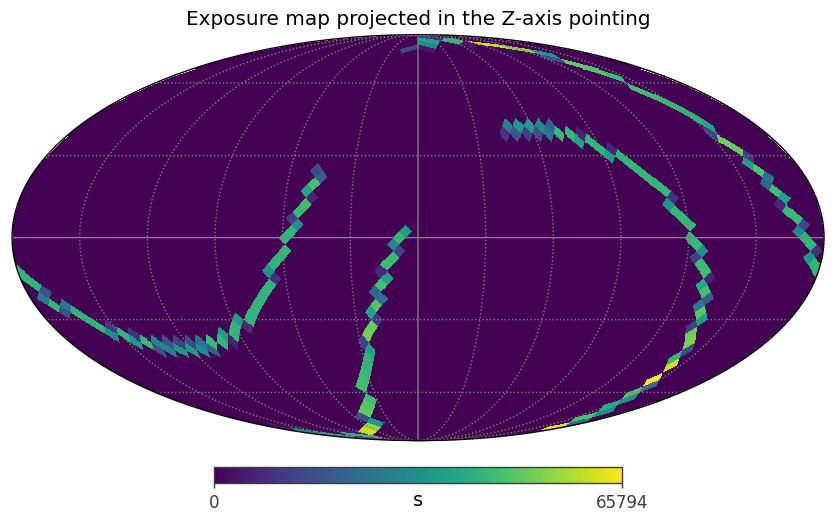

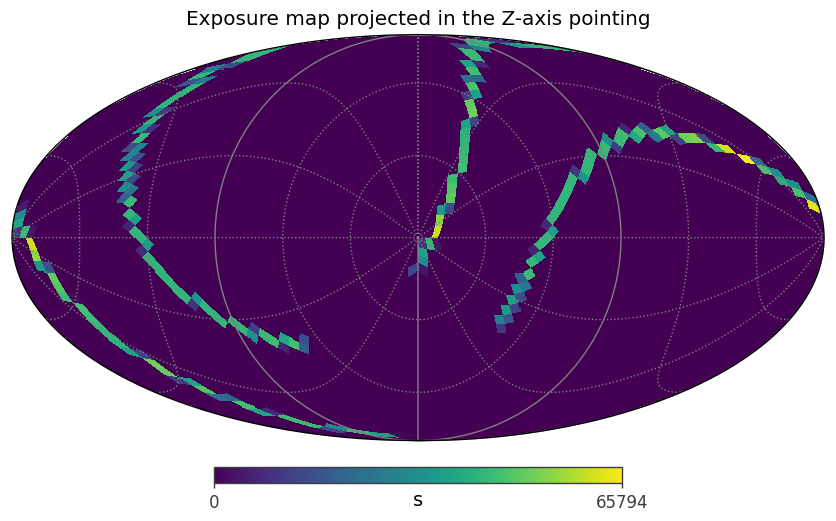

In [19]:
hp.mollview(map_pointing_zx.project('z').contents, rot=(0,0), unit = u.s, title = "Exposure map projected in the Z-axis pointing")
hp.graticule(color='gray', dpar = 30)
plt.show()

hp.mollview(map_pointing_zx.project('z').contents, rot=(0,90), unit = u.s, title = "Exposure map projected in the Z-axis pointing")
hp.graticule(color='gray', dpar = 30)
plt.show()

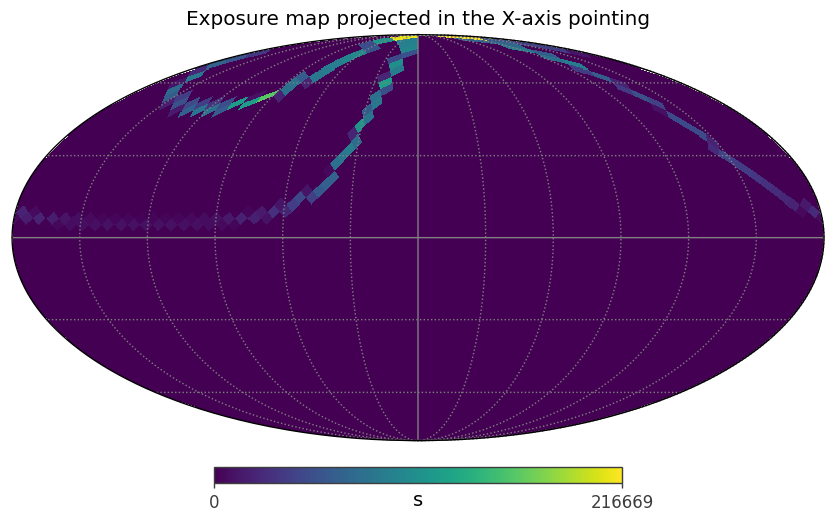

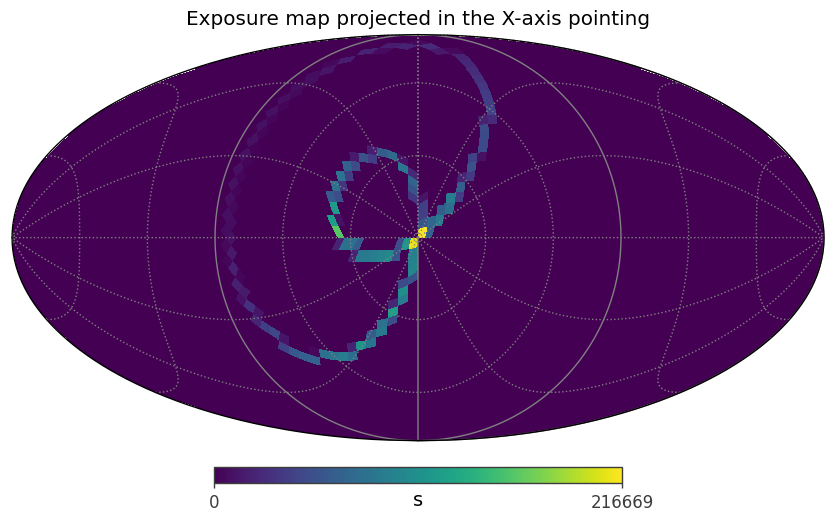

In [20]:
hp.mollview(map_pointing_zx.project('x').contents, rot=(0,0), unit = u.s, title = "Exposure map projected in the X-axis pointing")
hp.graticule(color='gray', dpar = 30)
plt.show()

hp.mollview(map_pointing_zx.project('x').contents, rot=(0,90), unit = u.s, title = "Exposure map projected in the X-axis pointing")
hp.graticule(color='gray', dpar = 30)
plt.show()

# 2. Calculate the coordinate conversion matrix

CoordsysConversionMatrix.spacecraft_attitude_binning_ccm can produce the coordinate conversion matrix for the spacecraft attitude binning. In this calculation, we calculate the exposure time map in the detector coordinate for each model pixel and each scatt_binning_index. We refer to it as the dwell time map.

If use_averaged_pointing is True, first the averaged Z- and X-pointings are calculated (the average of zpointing or xpointing in the exposure table) for each scatt_binning_index, and then the dwell time map is calculated assuming the averaged pointings for each model pixel and each scatt_binning_index.

If use_averaged_pointing is False, the dwell time map is calculated for each attitude in Z-pointing and X-pointing (every 15 seconds), and then the calculated dwell time maps are summed up for each model pixel and each scatt_binning_index. 

In the former case, the computation faster but may lose the angular resolution. In the latter case, the conversion matrix is more accurate, but it takes a very long time to calculate it.

**On a MacBook Pro with M2 Max and 96 GB memory, it takes 8 minutes to calculate the conversion matrix.**

In [25]:
%%time

nside_model = nside_local

coordsys_conv_matrix = CoordsysConversionMatrix.from_exposure_table(exposure_table, full_detector_response, nside_model = nside_model, use_averaged_pointing = True)

  0%|          | 0/3379 [00:00<?, ?it/s]

CPU times: user 1h 57min 35s, sys: 55.5 s, total: 1h 58min 30s
Wall time: 1h 58min 44s


You can save CoordsysConversionMatrix as a hdf5 file.

In [26]:
coordsys_conv_matrix.write("ccm.hdf5", overwrite = True)

You can also read the saved file.

In [7]:
coordsys_conv_matrix = CoordsysConversionMatrix.open("ccm.hdf5")

## check exposure time maps

In [9]:
exposure_table = SpacecraftAttitudeExposureTable.from_fits("exposure_table.fits")

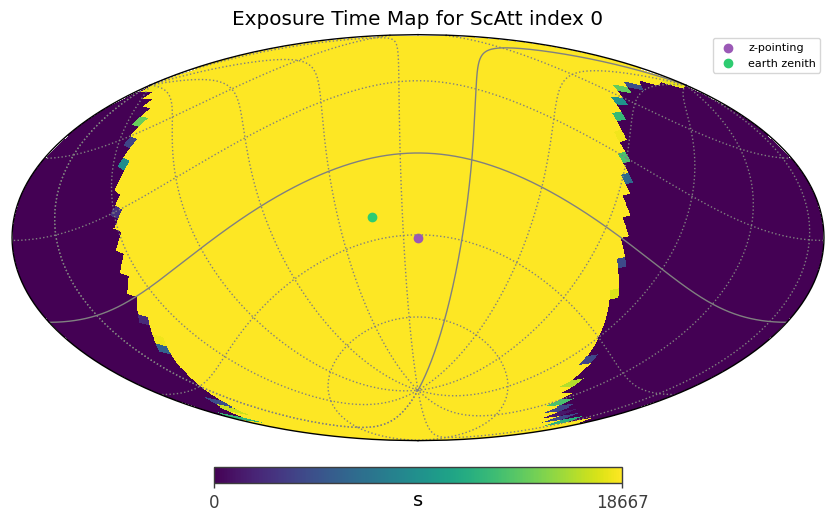

In [10]:
scatt_index = 0

zpointing_averaged = exposure_table.iloc[scatt_index]['zpointing_averaged']
earth_zenith = exposure_table.iloc[scatt_index]['earth_zenith'][0]

hp.mollview(np.sum(coordsys_conv_matrix[scatt_index], axis = 1).todense(), rot = zpointing_averaged, 
            unit = f'{coordsys_conv_matrix.unit}', title = f'Exposure Time Map for ScAtt index {scatt_index}')
hp.projscatter(zpointing_averaged[0], zpointing_averaged[1], lonlat = True, label = 'z-pointing')
hp.projscatter(earth_zenith[0], earth_zenith[1], lonlat = True, label = 'earth zenith')
hp.graticule(color='gray', dpar = 30)
plt.legend()

## check exposure maps

In [20]:
exposure_map = coordsys_conv_matrix.calc_exposure_map(full_detector_response)
exposure_map

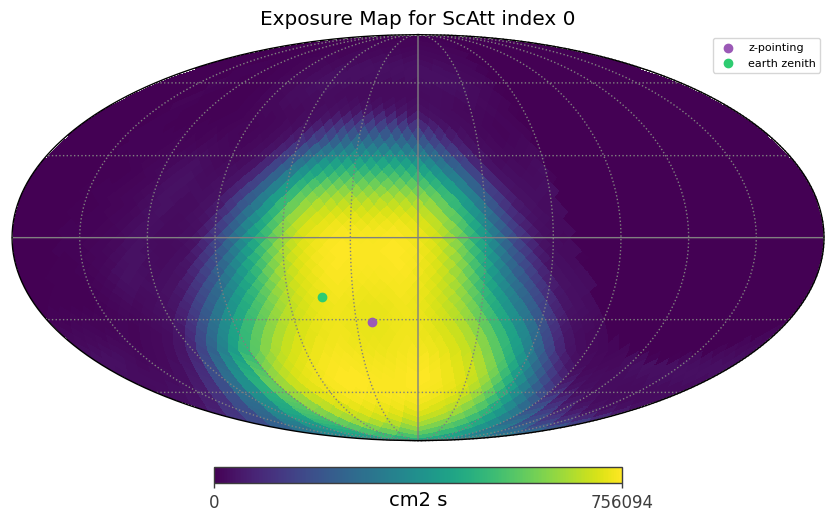

In [22]:
scatt_index = 0

zpointing_averaged = exposure_table.iloc[scatt_index]['zpointing_averaged']
earth_zenith = exposure_table.iloc[scatt_index]['earth_zenith'][0]

hp.mollview(exposure_map.slice[{'ScAtt': scatt_index, 'Ei': 0}].project('lb').contents, 
            unit = f'{exposure_map.unit}', title = f'Exposure Map for ScAtt index {scatt_index}')
hp.projscatter(zpointing_averaged[0], zpointing_averaged[1], lonlat = True, label = 'z-pointing')
hp.projscatter(earth_zenith[0], earth_zenith[1], lonlat = True, label = 'earth zenith')
hp.graticule(color='gray', dpar = 30)
plt.legend()

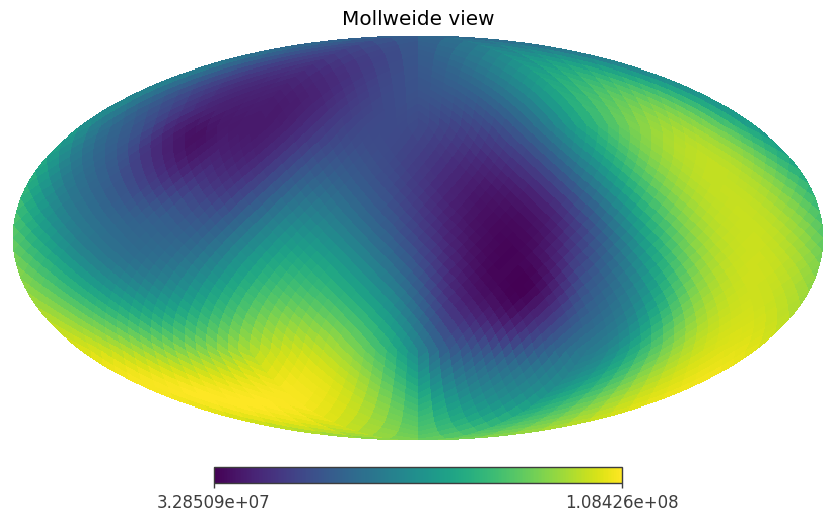

In [23]:
hp.mollview(exposure_map.slice[{'Ei': 0}].project('lb').contents)
plt.show()

# 3. produce the binned data

Using the exposure table, we can produce the binned data. Note that here we generate the binned histogram manually. We plan to implement this functionality in the DataIO class in the future.

Load the 511keV data (without background)

In [7]:
%%time

signal_filepath = "NFW_511_3months_unbinned_data_filtered_with_SAAcut.fits.gz"

unbinned_signal = UnBinnedData(input_yaml = "inputs_511keV.yaml")

unbinned_signal.cosi_dataset = unbinned_signal.get_dict_from_fits(signal_filepath)

binned_signal = exposure_table.get_binned_data(unbinned_signal, psichi_binning = 'local', sparse = False)

fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking


CPU times: user 1.16 s, sys: 41 ms, total: 1.2 s
Wall time: 1.21 s


Load the background data

In [10]:
%%time

bkg_filepath = "AlbedoPhotons_3months_unbinned_data_filtered_with_SAAcut.fits.gz"

unbinned_bkg = UnBinnedData(input_yaml = "inputs_511keV.yaml")

unbinned_bkg.cosi_dataset = unbinned_bkg.get_dict_from_fits(bkg_filepath)

binned_bkg = exposure_table.get_binned_data(unbinned_bkg, psichi_binning = 'local', sparse = False)

fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking


CPU times: user 35.7 s, sys: 2.6 s, total: 38.3 s
Wall time: 38.7 s


Sum up the signal and background data

In [11]:
binned_event = binned_signal + binned_bkg

Save them

In [12]:
binned_bkg.write(path_data + "511keV_scatt_bkg.hdf5")
binned_signal.write(path_data + "511keV_scatt_signal.hdf5")
binned_event.write(path_data + "511keV_scatt_event.hdf5")

**You can move on the next notebook (511keV-ScAtt-ImageDeconvolution.ipynb).**